In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent


import torch
import numpy as np
import matplotlib.pyplot as plt
from VAE import VAE

import torch.nn.functional as F

from helper import *


from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

from functools import partial

In [2]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)


In [3]:
folder = "Lid_Driven"

RE_MEAN = config["Stats"][folder]["Re_Mean"]
RE_STD = config["Stats"][folder]["Re_Std"]


U_CLIP_MIN = config["Stats"][folder]["U_CLIP_MIN"]
U_CLIP_MAX = config["Stats"][folder]["U_CLIP_MAX"]

V_CLIP_MIN = config["Stats"][folder]["V_CLIP_MIN"]
V_CLIP_MAX = config["Stats"][folder]["V_CLIP_MAX"]

P_CLIP_MIN = config["Stats"][folder]["P_CLIP_MIN"]
P_CLIP_MAX = config["Stats"][folder]["P_CLIP_MAX"]

In [4]:
stats = config['Stats'][folder]

dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/{folder}_domain", meta = folder, eps=0.001)
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [ ]:
@torch.no_grad()
def sample_ddpm(latent_grid_size: int, dit, vae, device, scheduler, number, **kwargs):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    boundaries = kwargs.get("boundaries", None)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                         torch.as_tensor(i).unsqueeze(0).to(device), 
                         torch.as_tensor(number).unsqueeze(0).to(device),
                         boundaries
                         )

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(x0_pred)
    return img_tensor


@torch.no_grad()
def sample_ddim(latent_grid_size, dit, vae, device, scheduler, number, num_steps = 100, seed = None, **kwargs):
    if seed is not None:
        torch.manual_seed(seed)
    
    boundaries = kwargs.get("boundaries", None)

    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    # e.g. [999, 979, 959, ..., 19, -1]  (evenly spaced, descending)
    step_indices = torch.linspace(0, 999, num_steps).long().flip(0)
    step_indices = torch.cat([step_indices, torch.tensor([-1])])  # -1 = terminal, x0

    for idx in tqdm(range(len(step_indices) - 1)):
        t = step_indices[idx].item()
        t_prev = step_indices[idx + 1].item()

        noise_pred = dit(xt,
                          torch.as_tensor(t).unsqueeze(0).to(device),
                          torch.as_tensor(number).unsqueeze(0).to(device),
                        #   boundaries,
                          )

        xt, x0_pred = scheduler.ddim_step(xt, noise_pred, t, t_prev, eta=0.0)

    img_tensor = vae.decode(x0_pred)
    return img_tensor

@torch.no_grad()
def sample_heun(latent_grid_size, dit, vae, device, scheduler, number, num_steps = 50, seed = None, tolerance = None, max_correction_iter=10, **kwargs):

    if seed is not None:
        torch.manual_seed(seed)

    boundaries = kwargs.get("boundaries", None)

    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size), device=device)


    step_indices = torch.linspace(999, 0, num_steps, device=device ).round().long()

    number_tensor = torch.as_tensor(number, device=device).unsqueeze(0)

    x0_pred = None

    # Reverse diffusion

    total_calls = 0

    for idx in tqdm(range(len(step_indices) - 1)):

        total_calls += 1

        t = step_indices[idx].item()
        t_next = step_indices[idx + 1].item()

        dt = float(t_next - t)

        t_tensor = torch.tensor([t], device=device, dtype=torch.long)

        t_next_tensor = torch.tensor([t_next], device=device, dtype=torch.long)

        # PREDICTOR

        # epsilon_theta(x_t, t)
        noise_t = dit(xt, t_tensor, number_tensor)#, boundaries)

        # k1 = f(x_t, t)
        k1 = scheduler.ddim_ode_derivative(xt, noise_t, t) 

        # x_next_pred =
        # x_t + dt * k1
        xt_pred = xt + dt * k1

        # CORRECTOR
        # epsilon_theta(x_next_pred, t_next)
        noise_next = dit(xt_pred, t_next_tensor, number_tensor)#, boundaries)

        # k2 = f(x_next_pred, t_next)
        k2 = scheduler.ddim_ode_derivative(xt_pred, noise_next, t_next)


        # HEUN UPDATE

        xt_new = (xt + 0.5 * dt * (k1 + k2))

        # OPTIONAL ITERATIVE CORRECTION
        if tolerance is not None:
            flag = False

            xt_corrected = xt_new

            for idx_c in range(max_correction_iter):
                total_calls += 1

                noise_correct = dit(xt_corrected, t_next_tensor, number_tensor)#, boundaries)
                k_correct = scheduler.ddim_ode_derivative(xt_corrected, noise_correct, t_next)

                # Fixed-point correction
                xt_next_iter = (xt + (dt * k_correct))
                error = (torch.norm(xt_next_iter - xt_corrected) / (torch.norm(xt_corrected) + 1e-8))
                xt_corrected = xt_next_iter

                if error < tolerance:
                    print(f"at step: {idx}, corrected in {idx_c}th correction step")
                    break

            xt = xt_corrected
            if idx_c == max_correction_iter - 1:
                print(f"at step: {idx}, corrected in {idx_c}th correction step, max iter reached")
        else:
            xt = xt_new

        # Calculate x0 at current final state
        alpha_next = scheduler.alpha_cum_prod.to(device=device, dtype=xt.dtype)[t_next]
        x0_pred = (xt - torch.sqrt(1.0 - alpha_next) * noise_next) / torch.sqrt(alpha_next)
        x0_pred = torch.clamp(x0_pred, -4, 4)
        
    # Decode

    img_tensor = vae.decode(x0_pred)
    print(total_calls)
    return img_tensor

@torch.no_grad()
def sample_heun_only(latent_grid_size, dit, vae, device, scheduler, number, num_steps=20, seed=None, **kwargs):

    if seed is not None:
        torch.manual_seed(seed)

    boundaries = kwargs.get("boundaries", None)

    # Initial noise
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size), device=device)

    # Timesteps: e.g. 999 -> ... -> 0
    step_indices = torch.linspace(999, 0, num_steps, device=device).round().long()

    number_tensor = torch.as_tensor(number, device=device).unsqueeze(0)

    total_calls = 0

    # Reverse diffusion
    for idx in tqdm(range(len(step_indices) - 1)):

        t = step_indices[idx].item()
        t_next = step_indices[idx + 1].item()

        dt = float(t_next - t)

        t_tensor = torch.tensor([t], device=device, dtype=torch.long)

        t_next_tensor = torch.tensor([t_next], device=device, dtype=torch.long)

        # 1. PREDICTOR
        # epsilon_theta(x_t, t)
        noise_t = dit(xt, t_tensor, number_tensor)

        total_calls += 1

        # k1 = f(x_t, t)
        k1 = scheduler.ddim_ode_derivative(xt, noise_t, t)

        # x_pred = x_t + dt * k1
        xt_pred = xt + dt * k1


        # 2. CORRECTOR

        # epsilon_theta(x_pred, t_next)
        noise_next = dit(xt_pred, t_next_tensor, number_tensor)

        total_calls += 1

        # k2 = f(x_pred, t_next)
        k2 = scheduler.ddim_ode_derivative(
            xt_pred,
            noise_next,
            t_next
        )


        # 3. HEUN UPDATE

        xt = xt + 0.5 * dt * (k1 + k2)


    # FINAL x0 PREDICTION

    t_final = step_indices[-1].item()

    t_final_tensor = torch.tensor(
        [t_final],
        device=device,
        dtype=torch.long
    )

    # Need epsilon prediction at the final latent
    noise_final = dit(
        xt,
        t_final_tensor,
        number_tensor
    )

    total_calls += 1

    alpha_final = scheduler.alpha_cum_prod.to(
        device=device,
        dtype=xt.dtype
    )[t_final]

    x0_pred = (
        xt
        - torch.sqrt(1.0 - alpha_final) * noise_final
    ) / torch.sqrt(alpha_final)

    x0_pred = torch.clamp(
        x0_pred,
        -4,
        4
    )

    # Decode
    img_tensor = vae.decode(x0_pred)

    print("Total DiT calls:", total_calls)

    return img_tensor

In [6]:
dit = DiT(d_model         = config["DiT"]["d_model"],
        g_channels        = config["DiT"]["g_channels"],
        grid_size         = config["DiT"]["grid_size"],
        patch_size        = config["DiT"]["patch_size"],
        timestep_emb_dim  = config["DiT"]["timestep_emb_dim"],
        number_emb_dim    = config["DiT"]["number_emb_dim"],
        num_layers        = config["DiT"]["num_layers"],
        num_heads         = config["DiT"]["num_heads"])

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse")

In [8]:
vae.eval()
dit.eval()

vae.load_state_dict(torch.load(f"{ROOT}/models/VAE.pth", map_location = device))
dit.load_state_dict(torch.load(f'{ROOT}/models/1_500_0.pth', map_location = device))

vae = vae.to(device)
dit = dit.to(device)

In [9]:
scheduler = LinearNoiseScheduler(num_timesteps  = config['Scheduler']['num_timesteps'],
                                     beta_start = config['Scheduler']['beta_start'],
                                     beta_end   = config['Scheduler']['beta_end'])

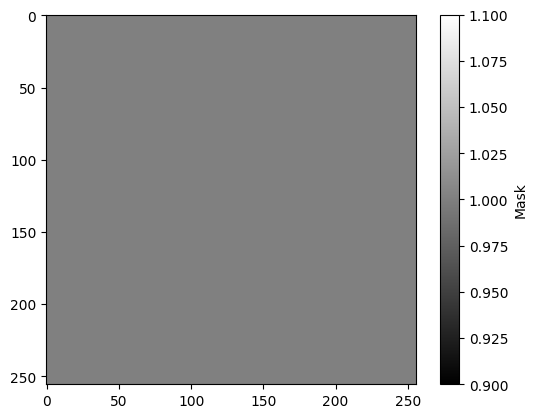

torch.Size([1, 256, 256])


In [11]:
m = torch.zeros(256, 256)

y_start = 0
y_end   = 1

x_start = 0
x_end   = 1

m[int(256*y_start):int(256*y_end),
  int(256*x_start):int(256*x_end)] = 1

plt.imshow(m, cmap="gray")
plt.colorbar(label="Mask")
plt.show()

m = m.unsqueeze(0)

print(m.shape)

100%|██████████| 20/20 [00:01<00:00, 17.30it/s]


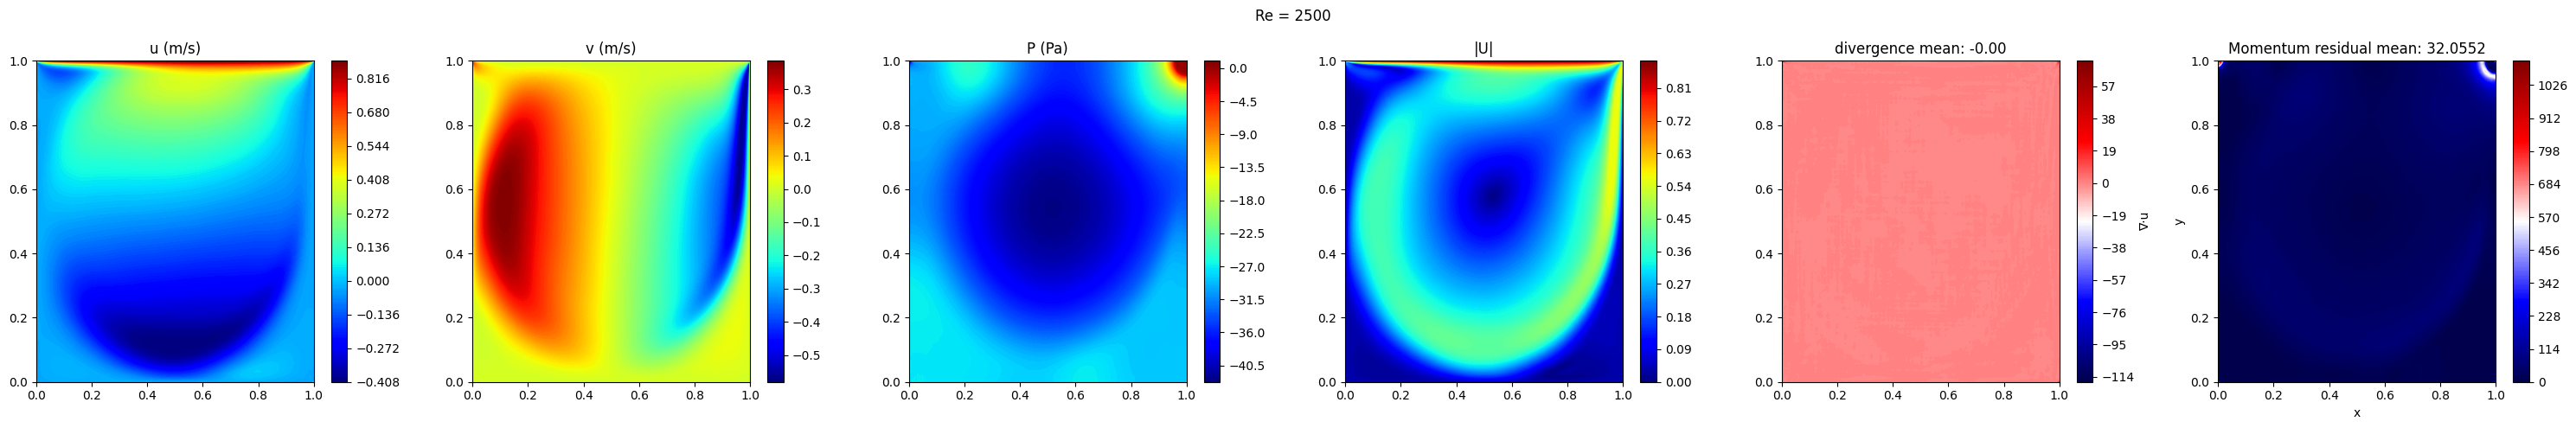

In [43]:
solver = sample_ddim
# solver = partial(solver, num_steps = 1) # DDIM 

u_grid_pred, v_grid_pred, p_grid_pred, div_pred, momentum_res_pred, mag_pred = predict(dit, vae, scheduler, re_value = 2500, sample_fn = solver, 
                                                                                        re_mean = RE_MEAN, re_std = RE_STD, 
                                                                                        u_clip_min = U_CLIP_MIN, u_clip_max = U_CLIP_MAX, 
                                                                                        v_clip_min = V_CLIP_MIN, v_clip_max = V_CLIP_MAX, 
                                                                                        P_clip_min = P_CLIP_MIN, P_clip_max = P_CLIP_MAX,
                                                                                        grid_size = 256,
                                                                                        device = device, plot = True,
                                                                                        
                                                                                        boundaries = m.flip((1,2)),
                                                                                        num_steps = 20
                                                                                        )

 11%|█         | 2/19 [00:01<00:10,  1.63it/s]

at step: 0, corrected in 0th correction step
at step: 1, corrected in 1th correction step


 21%|██        | 4/19 [00:01<00:05,  2.89it/s]

at step: 2, corrected in 1th correction step
at step: 3, corrected in 1th correction step


 32%|███▏      | 6/19 [00:02<00:03,  3.83it/s]

...

 95%|█████████▍| 18/19 [00:05<00:00,  3.52it/s]

at step: 17, corrected in 5th correction step


100%|██████████| 19/19 [00:06<00:00,  3.05it/s]

at step: 18, corrected in 19th correction step, max iter reached


82


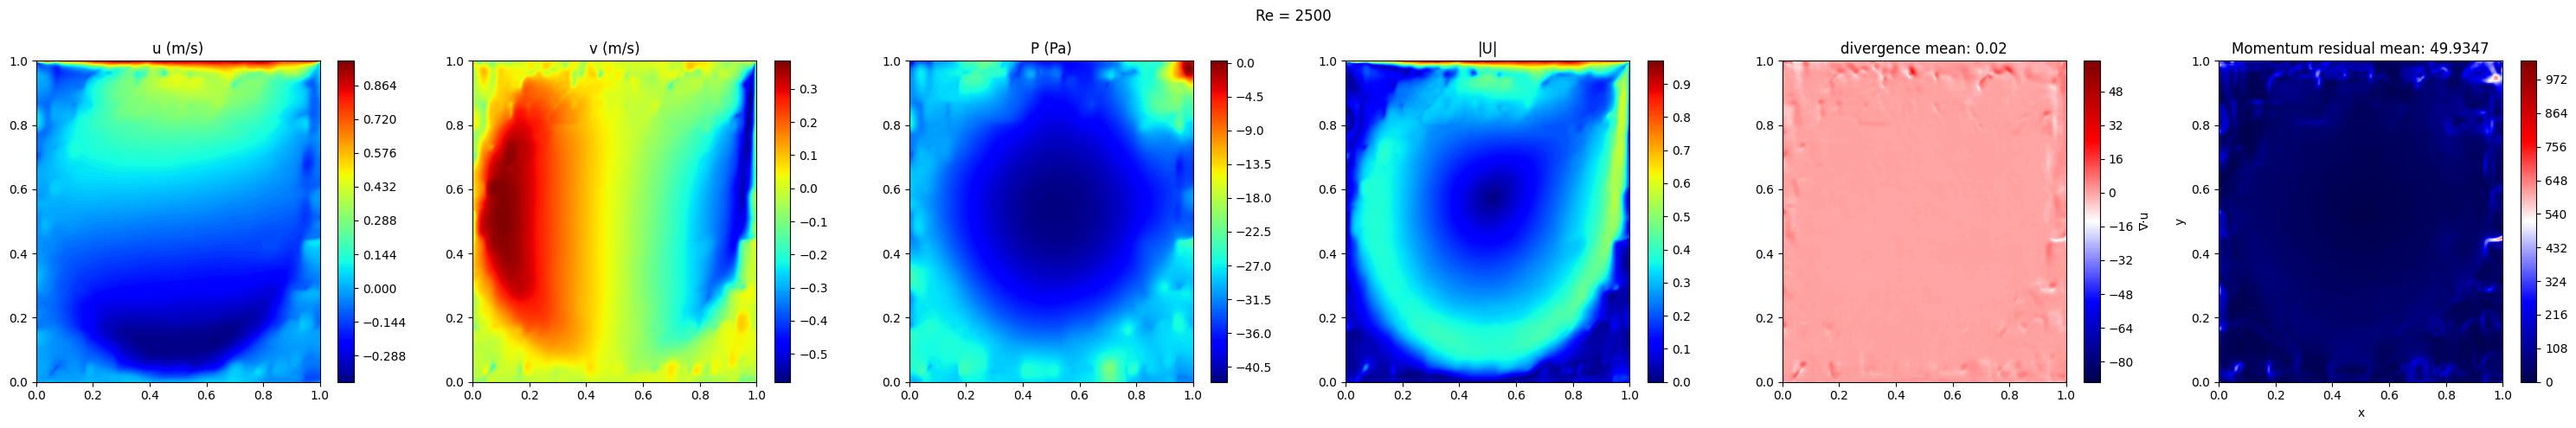

In [46]:
solver = sample_heun
# solver = partial(solver, num_steps = 10) # DDIM
# solver = partial(solver) # DDIM + Huen

u_grid_pred, v_grid_pred, p_grid_pred, div_pred, momentum_res_pred, mag_pred = predict(dit, vae, scheduler, re_value = 2500, sample_fn = solver, 
                                                                                        re_mean = RE_MEAN, re_std = RE_STD, 
                                                                                        u_clip_min = U_CLIP_MIN, u_clip_max = U_CLIP_MAX, 
                                                                                        v_clip_min = V_CLIP_MIN, v_clip_max = V_CLIP_MAX, 
                                                                                        P_clip_min = P_CLIP_MIN, P_clip_max = P_CLIP_MAX,
                                                                                        grid_size = 256,
                                                                                        device = device, plot = True,

                                                                                        boundaries = m,
                                                                                        num_steps = 20,
                                                                                        tolerance = 1e-3,
                                                                                        max_correction_iter = 20
                                                                                        )

100%|██████████| 19/19 [00:01<00:00,  9.96it/s]


Total DiT calls: 39


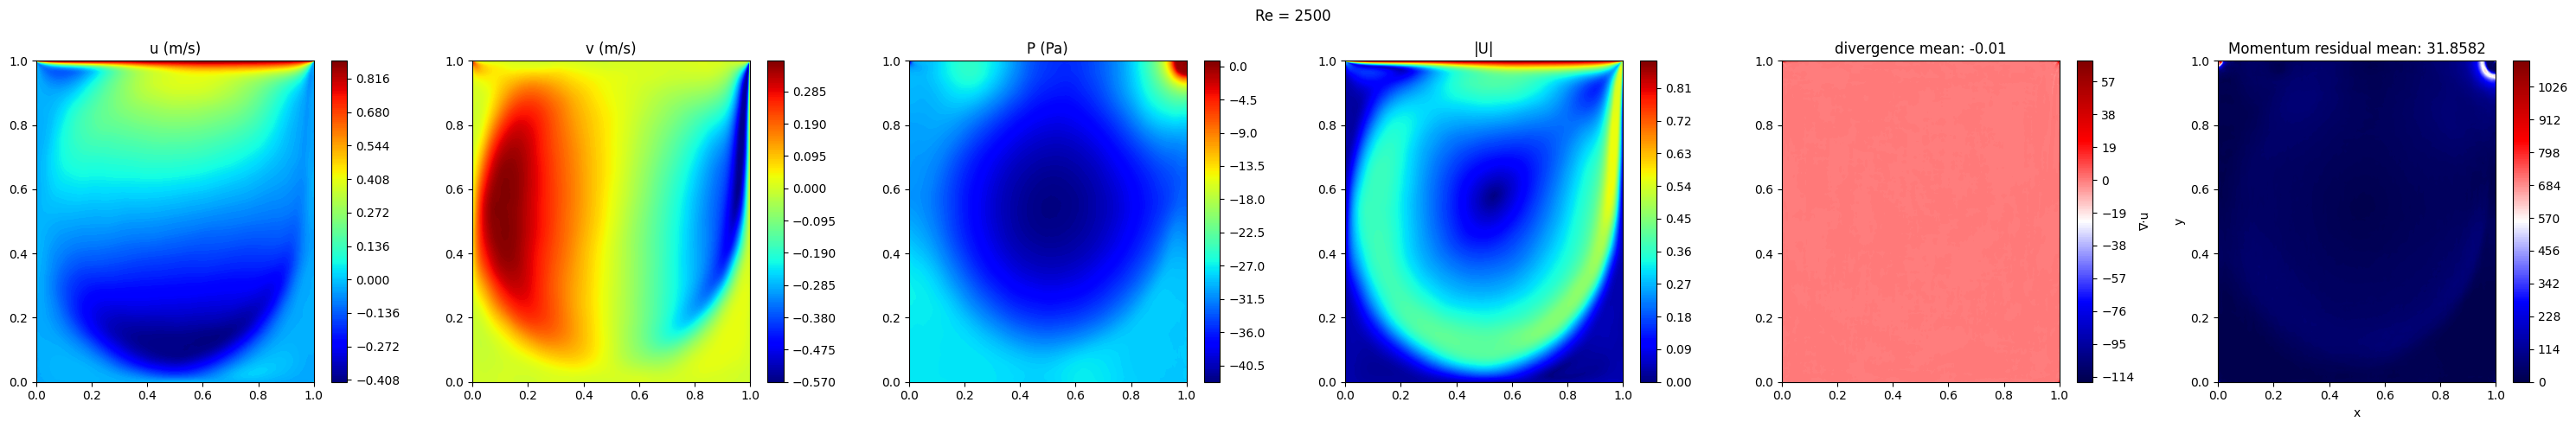

In [42]:
solver = sample_heun_only
# solver = partial(solver, num_steps = 10) # DDIM
# solver = partial(solver) # DDIM + Huen only

u_grid_pred, v_grid_pred, p_grid_pred, div_pred, momentum_res_pred, mag_pred = predict(dit, vae, scheduler, re_value = 2500, sample_fn = solver, 
                                                                                        re_mean = RE_MEAN, re_std = RE_STD, 
                                                                                        u_clip_min = U_CLIP_MIN, u_clip_max = U_CLIP_MAX, 
                                                                                        v_clip_min = V_CLIP_MIN, v_clip_max = V_CLIP_MAX, 
                                                                                        P_clip_min = P_CLIP_MIN, P_clip_max = P_CLIP_MAX,
                                                                                        grid_size = 256,
                                                                                        device = device, plot = True,

                                                                                        boundaries = m,
                                                                                        num_steps = 20
                                                                                        )